In [ ]:
from skimage.segmentation import watershed, felzenszwalb
from skimage.filters import sobel
import pandas as pd
from pathlib import Path
import cv2
import pickle
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from skimage.filters import rank
from scipy import ndimage as ndi
from skimage.morphology import disk
import sklearn.metrics

In [ ]:


# downloading the images

!wget https://challengedata.ens.fr/media/public/train-images.zip

!wget https://challengedata.ens.fr/media/public/test-images.zip
!wget https://challengedata.ens.fr/media/public/label_Hnl61pT.csv -O y_train.csv

In [ ]:
!unzip train-images.zip
!unzip test-images.zip

# Handling the data

In [ ]:
# Load the train labels
# Note the transpose!
labels_train = pd.read_csv("y_train.csv", index_col=0).T

In [ ]:
# Here is a function to load the data
def load_dataset(dataset_dir):
    dataset_list = []
    # Note: It's very important to load the images in the correct numerical order!
    for image_file in list(sorted(Path(dataset_dir).glob("*.png"), key=lambda filename: int(filename.name.rstrip(".png")))):
        dataset_list.append(cv2.imread(str(image_file), cv2.IMREAD_GRAYSCALE))
    return np.stack(dataset_list, axis=0)

In [ ]:
# Load the train and test sets
# If you've put the shortcut directly in your drive, this should work out of the box
# Else, edit the path
data_dir = Path("./")
data_train = load_dataset(data_dir / "train-images")
data_test = load_dataset(data_dir / "test-images")

In [ ]:
# The train data is a numpy array of 1000 images of 512*512
print(f"X_train shape: {data_train.shape}")
# The train label is a dataframe of 1000 rows with 262144 (=512x512) columns
print(f"Y_train shape: {labels_train.shape}")

X_train shape: (2000, 256, 256)
Y_train shape: (2000, 65536)


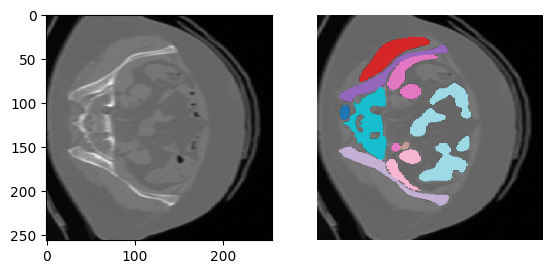

In [ ]:
# Let's display some data
# Here is a function to display side by side a slide and a segmented mask
def plot_slice_seg(slice_image, seg):
    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(slice_image, cmap="gray")
    axes[1].imshow(slice_image, cmap="gray")
    seg_masked = np.ma.masked_where(seg.reshape((256,256)) == 0, (seg.reshape((256,256))))
    axes[1].imshow(seg_masked, cmap="tab20")
    plt.axis("off")

# Let's try it on a slide and ites segmentation mask
# Note: we have to reshape the rows of the dataframe into a 256*256 matrix
plot_slice_seg(data_train[0], labels_train.iloc[0].values.reshape((256,256)))

## Let's compute a baseline

In [ ]:
# Let's take a very basic watershed baseline
def compute_baseline_one_sample(data_slice):
    edges = sobel(data_slice)
    denoised = rank.median(data_slice, disk(2))
    markers = rank.gradient(denoised, disk(5)) < 20
    markers = ndi.label(markers)[0]
    label_predicted = watershed(edges, markers=markers, compactness=0.0001)
    return label_predicted

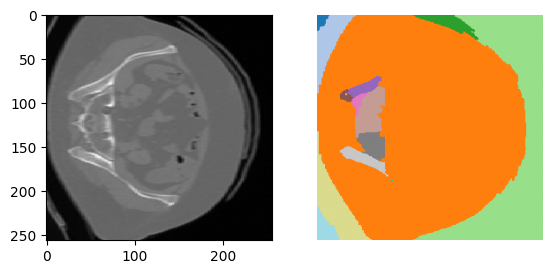

In [ ]:
# Let's display the results
# Not too bad!
plot_slice_seg(data_train[0], compute_baseline_one_sample(data_train[0]))

## Fine tuning with labels

In [ ]:
!pip install ultralytics

### Fine tune Yolo

In [ ]:
def get_bounding_boxes_per_connected_components(image):
    """
    Trouve les boîtes englobantes pour chaque classe présente dans une image segmentée.

    :param image: np.array 2D où chaque pixel a une valeur correspondant à une classe.
    :return: list [(x_min, y_min, x_max, y_max), ...]
    """
    bounding_boxes = []

    unique_classes = np.unique(image)  # Trouver les classes uniques

    for cls in unique_classes:
        if cls == 0:  # Supposons que 0 représente le fond, on l'ignore
            continue

        mask = (image == cls).astype(np.uint8)  # Créer un masque binaire
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

        for i in range(1, num_labels):  # On ignore le label 0 (le fond)
            x, y, w, h, _ = stats[i]
            bounding_boxes.append([cls-1, x, y, x + w, y + h])  # (x_min, y_min, x_max, y_max)

    return bounding_boxes

In [ ]:
import numpy as np

def get_bounding_boxes_per_class(image):
    """
    Trouve une seule boîte englobante pour chaque classe présente dans une image segmentée.

    :param image: np.array 2D où chaque pixel a une valeur correspondant à une classe.
    :return: list [(classe, x_min, y_min, x_max, y_max), ...]
    """
    bounding_boxes = []

    unique_classes = np.unique(image)  # Trouver les classes uniques

    for cls in unique_classes:
        if cls == 0:  # Supposons que 0 représente le fond, on l'ignore
            continue

        # Trouver les indices des pixels appartenant à la classe actuelle
        y_indices, x_indices = np.where(image == cls)

        if len(x_indices) == 0 or len(y_indices) == 0:
            continue  # Éviter les erreurs si la classe est vide (ce qui ne devrait pas arriver)

        # Déterminer les coordonnées de la boîte englobante
        x_min, x_max = np.min(x_indices), np.max(x_indices)
        y_min, y_max = np.min(y_indices), np.max(y_indices)

        bounding_boxes.append((cls-1, x_min, y_min, x_max, y_max))

    return bounding_boxes


In [ ]:
import albumentations as A
def augment_image(image, bboxes, num_augmentations=5, zoom_range=(0.9, 1.1), blur_prob = 0.2):
    """
    Apply multiple crops and zoom augmentations while adjusting bounding boxes.

    :param image: Input image (numpy array)
    :param bboxes: List of bounding boxes in [x_min, y_min, x_max, y_max] format
    :param num_crops: Number of augmented images to generate
    :param zoom_range: Tuple (min_zoom, max_zoom) for zoom augmentation
    :return: List of augmented images and corresponding bounding boxes
    """
    height, width = image.shape[:2]
    aug_images = []
    aug_bboxes = []

    transform = A.Compose([
        A.RandomCrop(width=int(width * 0.9), height=int(height * 0.9), p=1.0),
        A.RandomScale(scale_limit=(zoom_range[0] - 1, zoom_range[1] - 1), p=1.0),
        A.OneOf([
            A.Blur(blur_limit=5, p=blur_prob),  # Standard blur
            A.GaussianBlur(blur_limit=(3, 7), p=blur_prob),  # Gaussian blur
            A.MedianBlur(blur_limit=5, p=blur_prob)  # Median blur
        ], p=blur_prob)
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['category']))
    category = [b[0]  for b in bboxes]
    boxesxyxy = [b[1:] for b in bboxes]
    for _ in range(num_augmentations):
        augmented = transform(image=image, bboxes=boxesxyxy, category=category)

        aug_images.append(augmented["image"])
        aug_bboxes.append([[c] + [int(x) for x in l] for c,l in zip(augmented["category"],augmented["bboxes"])])

    return aug_images, aug_bboxes

In [ ]:
def show_image_with_boxes(image, boxes):
    """
    Display an image with bounding boxes drawn around detected objects.

    :param image: np.array 2D where each pixel has a value corresponding to a class.
    :param boxes: dict {class_id: [(x_min, y_min, x_max, y_max), ...]}
    """
    img_height, img_width = image.shape

    # Convert the image to RGB for visualization
    img_vis = (image * (255 / image.max())).astype(np.uint8)
    img_vis = cv2.cvtColor(img_vis, cv2.COLOR_GRAY2RGB)  # Convert grayscale to color

    # Assign a color for each class
    colors = {cls: (np.random.randint(0, 255), np.random.randint(0, 255), np.random.randint(0, 255)) for cls in range(0,55)}

    for idx, box in enumerate(boxes):
        cls, x_min, y_min, x_max, y_max = box
        color = colors[cls]

        cv2.rectangle(img_vis, (x_min, y_min), (x_max, y_max), color, 2)

    # Show the image with bounding boxes
    plt.figure(figsize=(6, 6))
    plt.imshow(img_vis)
    plt.axis("off")
    plt.show()

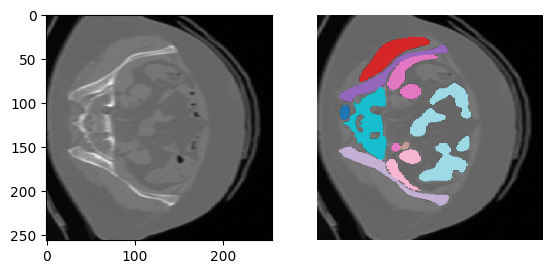

In [ ]:
plot_slice_seg(image, labels_train.iloc[0].values.reshape((256,256)))

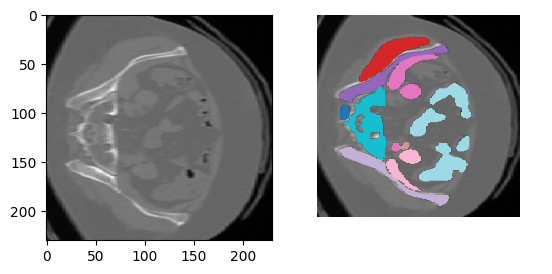

In [ ]:
plot_slice_seg(aug_images[0], labels_train.iloc[0].values.reshape((256,256)))

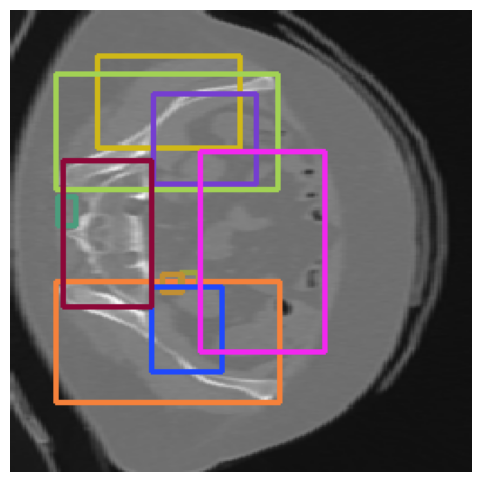

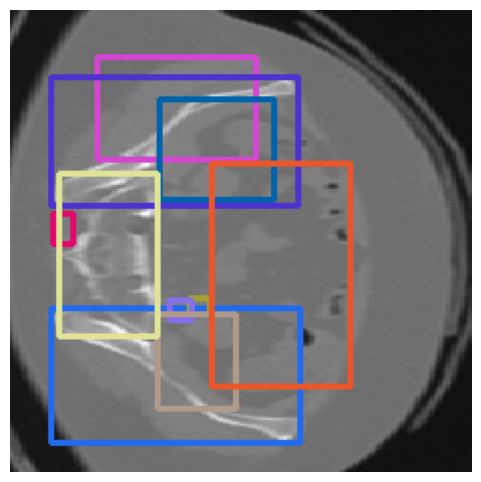

In [ ]:
image, boxes = data_train[0], get_bounding_boxes_per_class(labels_train.iloc[0].values.reshape((256,256)))
aug_images, aug_bboxes = augment_image(image, boxes, num_augmentations=5, zoom_range=(1, 1), blur_prob = 0.5)
show_image_with_boxes(image, boxes)
show_image_with_boxes(aug_images[0], aug_bboxes[0])

In [ ]:
plot_slice_seg(data_train[0], labels_train.iloc[0].values.reshape((256,256)))

In [ ]:
show_image_with_boxes(data_train[0], get_bounding_boxes(labels_train.iloc[0].values.reshape((256,256))))

In [ ]:
def convert_to_yolo_format(boxes, img_width, img_height):
    yolo_annotations = []

    for box in boxes:

        cls, x_min, y_min, x_max, y_max =  box
        x_center = (x_min + x_max) / 2.0 / img_width
        y_center = (y_min + y_max) / 2.0 / img_height
        width = (x_max - x_min) / img_width
        height = (y_max - y_min) / img_height

        yolo_annotations.append(f"{cls} {x_center} {y_center} {width} {height}")  # Class ID is 0 (struct)

    return yolo_annotations

def save_yolo_dataset(image_array, output_dir, img_name="image1"):
    os.makedirs(output_dir, exist_ok=True)

    img_height, img_width = image_array.shape
    boxes = get_bounding_boxes_per_class(image_array)

    yolo_data = convert_to_yolo_format(boxes, img_width, img_height)

    label_file = os.path.join(output_dir, f"{img_name}.txt")
    with open(label_file, "w") as f:
        f.write("\n".join(yolo_data))

    img_file = os.path.join(output_dir, f"{img_name}.png")
    cv2.imwrite(img_file, (image_array * (255 / image_array.max())).astype(np.uint8))

    print(f"Saved {label_file} and {img_file}")

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import yaml
from tqdm import tqdm
from PIL import Image

def annotate_per_connected_component(data, data_mask, data_size, data_dir):
    image_dir = f'{data_dir}/images'
    label_dir = f'{data_dir}/labels'
    os.makedirs(image_dir, exist_ok=True)
    os.makedirs(label_dir, exist_ok=True)
    num_augmentations = 5
    for i, d in enumerate(tqdm(data, desc="Processing Images")):
        image_path = f'{image_dir}/{i:06d}.png'
        label_path = f'{label_dir}/{i:06d}.txt'

        # Convert NumPy array to PIL image before processing
        image = Image.fromarray(d)
        # image = image.resize((640, 640))

        image.save(image_path)

        # Load image and extract bounding boxes
        image_source = np.array(image)  # Convert back to NumPy array
        img_height, img_width = image_source.shape  # Ensure proper unpacking

        boxes = get_bounding_boxes_per_connected_components(data_mask.iloc[i].values.reshape((256,256)))

        aug_images, aug_bboxes = augment_image(image_source, boxes, num_augmentations=num_augmentations, zoom_range=(0.9, 1.0), blur_prob = 0.5)
        boxes = convert_to_yolo_format(boxes, 256, 256)

        # Convert labels to YOLO format
        label = [b for b in boxes]
        label = '\n'.join(label)

        # Save label file
        with open(label_path, 'w') as f:
            f.write(label)


        # data augmentation
        for j in range(num_augmentations):
            image_path = f'{image_dir}/{i:06d}_{j:02d}.png'
            label_path = f'{label_dir}/{i:06d}_{j:02d}.txt'
            aug_images[j] = Image.fromarray(aug_images[j])
            aug_images[j].save(image_path)
            boxes = convert_to_yolo_format(aug_bboxes[j], 256, 256)

            label = [b for b in boxes]
            label = '\n'.join(label)

            # Save label file
            with open(label_path, 'w') as f:
                f.write(label)

# Annotate train and validation datasets
annotate_per_connected_component(data_train[:790], labels_train, 790, '/content/drive/MyDrive/data/yolo/connected_component/train')
annotate_per_connected_component(data_train[790:800],labels_train, 10, '/content/drive/MyDrive/data/yolo/connected_component/valid')

# Create dataset config file
config = {
    'names': [i for i in range(0, 54)],
    'nc': 54,
    'train': '/content/drive/MyDrive/data/yolo/connected_component/train/images',
    'val': '/content/drive/MyDrive/data/yolo/connected_component/valid/images'
}

with open('/content/drive/MyDrive/data/yolo/connected_component/data.yaml', 'w') as f:
    yaml.dump(config, f)


Processing Images: 100%|██████████| 10/10 [00:01<00:00,  7.36it/s]


In [ ]:
from math import e
import os
import numpy as np
import yaml
from tqdm import tqdm
from PIL import Image

def annotate_per_per_class(data, data_mask, data_size, data_dir):
    image_dir = f'{data_dir}/images'
    label_dir = f'{data_dir}/labels'
    os.makedirs(image_dir, exist_ok=True)
    os.makedirs(label_dir, exist_ok=True)
    num_augmentations = 5
    for i, d in enumerate(tqdm(data, desc="Processing Images")):
        try:
          image_path = f'{image_dir}/{i:06d}.png'
          label_path = f'{label_dir}/{i:06d}.txt'

          # Convert NumPy array to PIL image before processing
          image = Image.fromarray(d)
          # image = image.resize((640, 640))

          image.save(image_path)

          # Load image and extract bounding boxes
          image_source = np.array(image)  # Convert back to NumPy array
          img_height, img_width = image_source.shape  # Ensure proper unpacking

          boxes = get_bounding_boxes_per_class(data_mask.iloc[i].values.reshape((256,256)))

          aug_images, aug_bboxes = augment_image(image_source, boxes, num_augmentations=num_augmentations, zoom_range=(0.9, 1.1), blur_prob = 0.2)

          boxes = convert_to_yolo_format(boxes, 256, 256)

          # Convert labels to YOLO format
          label = [b for b in boxes]
          label = '\n'.join(label)

          # Save label file
          with open(label_path, 'w') as f:
              f.write(label)


          # data augmentation
          for j in range(num_augmentations):
              image_path = f'{image_dir}/{i:06d}_{j:02d}.png'
              label_path = f'{label_dir}/{i:06d}_{j:02d}.txt'
              aug_images[j] = Image.fromarray(aug_images[j])
              aug_images[j].save(image_path)
              boxes = convert_to_yolo_format(aug_bboxes[j], 256, 256)

              label = [b for b in boxes]
              label = '\n'.join(label)

              # Save label file
              with open(label_path, 'w') as f:
                  f.write(label)
        except:
          print(f"Error with image {i}")

# Annotate train and validation datasets
annotate_per_per_class(data_train[:790], labels_train, 790, '/content/drive/MyDrive/data/yolo/classes/train')
annotate_per_per_class(data_train[790:800],labels_train, 10, '/content/drive/MyDrive/data/yolo/classes/valid')

# Create dataset config file
config = {
    'names': [i for i in range(0, 54)],
    'nc': 54,
    'train': '/content/drive/MyDrive/data/yolo/classes/train/images',
    'val': '/content/drive/MyDrive/data/yolo/classes/valid/images'
}

with open('/content/drive/MyDrive/data/yolo/classes/data.yaml', 'w') as f:
    yaml.dump(config, f)


Processing Images:   2%|▏         | 13/790 [00:02<02:01,  6.39it/s]

Error with image 13


Processing Images:  18%|█▊        | 146/790 [00:26<01:20,  8.04it/s]

Error with image 144


Processing Images:  35%|███▍      | 276/790 [00:48<01:01,  8.34it/s]

...

Processing Images:  87%|████████▋ | 691/790 [01:59<00:14,  6.65it/s]

Error with image 689


Processing Images: 100%|█████████▉| 788/790 [02:15<00:00,  4.98it/s]

Error with image 788


Processing Images: 100%|██████████| 10/10 [00:01<00:00,  6.70it/s]


In [ ]:
from ultralytics import YOLO

yolo = YOLO('yolo11n.pt')
yolo.train(data='/content/drive/MyDrive/data/yolo/connected_component/data.yaml', epochs=15) # chose between connected components and classes
valid_results = yolo.val()
print(valid_results)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.35M/5.35M [00:00<00:00, 83.0MB/s]


Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/drive/MyDrive/data/yolo/connected_component/data.yaml, epochs=15, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_lab

100%|██████████| 755k/755k [00:00<00:00, 20.6MB/s]


Overriding model.yaml nc=80 with nc=54

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytic

...


15 epochs completed in 0.468 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 5.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,592,682 parameters, 0 gradients, 6.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.26it/s]


                   all         60        467    0.00213     0.0583    0.00375   0.000632
                     2          6          6          0          0          0          0
                     3         30         30          0          0          0          0
                     4          6          6    0.00242        0.5    0.00184   0.000708
                     8          6          6          0          0          0          0
                     9          6          6          0          0          0          0
                    11         12         12          0          0          0          0
                    15          6          6          0          0          0          0
                    17         12         12     0.0128      0.167     0.0125    0.00251
                    18         18         18          0          0          0          0
                    19          6          6          0          0          0          0
                    2

val: Scanning /content/drive/MyDrive/data/yolo/connected_component/valid/labels.cache... 60 images, 6 backgrounds, 0 corrupt: 100%|██████████| 60/60 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:02<00:00,  1.54it/s]


                   all         60        467    0.00211     0.0583    0.00372   0.000693
                     2          6          6          0          0          0          0
                     3         30         30          0          0          0          0
                     4          6          6    0.00239        0.5    0.00182     0.0007
                     8          6          6          0          0          0          0
                     9          6          6          0          0          0          0
                    11         12         12          0          0          0          0
                    15          6          6          0          0          0          0
                    17         12         12     0.0129      0.167     0.0127    0.00255
                    18         18         18          0          0          0          0
                    19          6          6          0          0          0          0
                    2

In [ ]:
import torch
import numpy as np
from ultralytics import YOLO


# Set device for computation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Load the YOLO model
# -------------------------
yolo_model = YOLO("runs/detect/train/weights/best.pt")


0: 640x640 6 8s, 2 22s, 2 23s, 1 31, 1 33, 1 43, 2 46s, 14.4ms
Speed: 3.5ms preprocess, 14.4ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


<ipython-input-32-1c6d1b7f2743>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cls = int(clses[i])


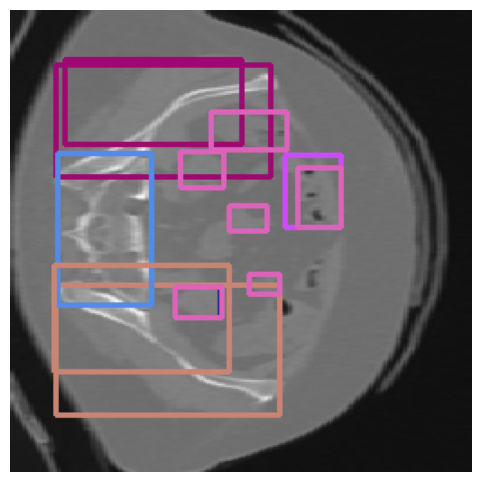

In [ ]:
if len(data_train[0].shape) == 2:  # Shape: (H, W)
      data_slice = np.stack([data_train[0]] * 3, axis=-1)

results = yolo_model(data_slice, conf=0.08)
clses = results[0].boxes.cls.unsqueeze(1).cpu().numpy()
# get the class associated to a box
boxes = yolo_to_xyxy(results[0].boxes.xywhn.cpu().numpy(), 256, 256)
list_box = []

for i, box in enumerate(boxes):
  x_min, y_min, x_max, y_max  = box
  cls = int(clses[i])
  list_box.append((cls, x_min, y_min, x_max, y_max))

show_image_with_boxes(data_train[0], list_box)

In [ ]:
from ultralytics import YOLO

yolo = YOLO('yolo11n.pt')
yolo.train(data='/content/drive/MyDrive/data/yolo/classes/data.yaml', epochs=15) # chose between connected components and classes
valid_results = yolo.val()
print(valid_results)

Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/drive/MyDrive/data/yolo/classes/data.yaml, epochs=15, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, s

train: Scanning /content/drive/MyDrive/data/yolo/classes/train/labels... 4674 images, 262 backgrounds, 0 corrupt: 100%|██████████| 4685/4685 [25:11<00:00,  3.10it/s]


train: New cache created: /content/drive/MyDrive/data/yolo/classes/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /content/drive/MyDrive/data/yolo/classes/valid/labels... 60 images, 6 backgrounds, 0 corrupt: 100%|██████████| 60/60 [00:38<00:00,  1.56it/s]

val: New cache created: /content/drive/MyDrive/data/yolo/classes/valid/labels.cache


...


15 epochs completed in 0.439 hours.
Optimizer stripped from runs/detect/train3/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train3/weights/best.pt, 5.5MB

Validating runs/detect/train3/weights/best.pt...
Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,592,682 parameters, 0 gradients, 6.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.37it/s]


                   all         60        318    0.00543     0.0736     0.0155    0.00282
                     2          6          6          0          0          0          0
                     3         30         30   0.000572     0.0333   0.000321   3.21e-05
                     4          6          6    0.00369      0.667    0.00631     0.0022
                     8          6          6          0          0          0          0
                     9          6          6          0          0          0          0
                    11         12         12          0          0          0          0
                    15          6          6          0          0          0          0
                    17         12         12     0.0106     0.0833     0.0155    0.00155
                    18         18         18     0.0132     0.0556     0.0075    0.00216
                    19          6          6          0          0          0          0
                    2

val: Scanning /content/drive/MyDrive/data/yolo/classes/valid/labels.cache... 60 images, 6 backgrounds, 0 corrupt: 100%|██████████| 60/60 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:02<00:00,  1.89it/s]


                   all         60        318    0.00538     0.0736     0.0154    0.00281
                     2          6          6          0          0          0          0
                     3         30         30   0.000575     0.0333   0.000323   3.23e-05
                     4          6          6    0.00368      0.667    0.00625    0.00211
                     8          6          6          0          0          0          0
                     9          6          6          0          0          0          0
                    11         12         12          0          0          0          0
                    15          6          6          0          0          0          0
                    17         12         12     0.0104     0.0833     0.0154    0.00154
                    18         18         18      0.013     0.0556    0.00736    0.00211
                    19          6          6          0          0          0          0
                    2

In [ ]:
import torch
import numpy as np
from ultralytics import YOLO


# Set device for computation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Load the YOLO model
# -------------------------
yolo_model = YOLO("runs/detect/train3/weights/best.pt")


0: 640x640 1 8, 2 17s, 1 18, 1 22, 2 23s, 2 30s, 1 46, 10.1ms
Speed: 3.0ms preprocess, 10.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


<ipython-input-41-81f21bdaa9ea>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cls = int(clses[i])


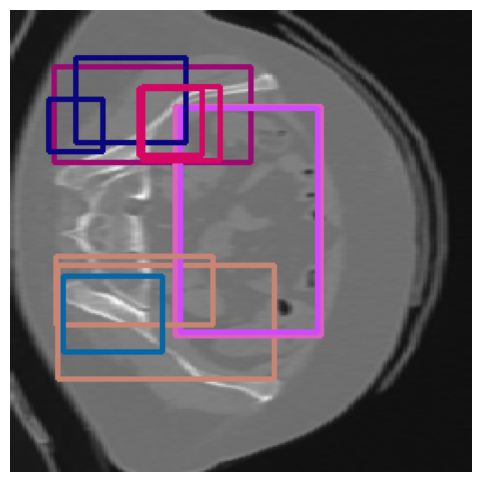

In [ ]:
if len(data_train[0].shape) == 2:  # Shape: (H, W)
      data_slice = np.stack([data_train[0]] * 3, axis=-1)

results = yolo_model(data_slice, conf=0.06)
clses = results[0].boxes.cls.unsqueeze(1).cpu().numpy()
# get the class associated to a box
boxes = yolo_to_xyxy(results[0].boxes.xywhn.cpu().numpy(), 256, 256)
list_box = []

for i, box in enumerate(boxes):
  x_min, y_min, x_max, y_max  = box
  cls = int(clses[i])
  list_box.append((cls, x_min, y_min, x_max, y_max))

show_image_with_boxes(data_train[0], list_box)

### Fine Tune Sam

Install Sam

In [ ]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

In [ ]:
!git clone https://github.com/facebookresearch/segment-anything-2
%cd /content/segment-anything-2
!pip install -q -e .

Cloning into 'segment-anything-2'...
remote: Enumerating objects: 1070, done.
remote: Total 1070 (delta 0), reused 0 (delta 0), pack-reused 1070 (from 1)
Receiving objects: 100% (1070/1070), 134.70 MiB | 10.69 MiB/s, done.
Resolving deltas: 100% (376/376), done.
/content/segment-anything-2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 162.4 kB/s eta 0:00:00
  Building editable for SAM-2 (pyproject.toml) ... done


Create the dataset

In [ ]:
def get_masks(image):
    """
    Trouve les boîtes englobantes pour chaque classe présente dans une image segmentée.

    :param image: np.array 2D où chaque pixel a une valeur correspondant à une classe.
    :return: dict {classe: [(x_min, y_min, x_max, y_max), ...]}
    """
    masks = []

    unique_classes = np.unique(image)  # Trouver les classes uniques

    for cls in unique_classes:
        if cls == 0:  # Supposons que 0 représente le fond, on l'ignore
            continue

        mask = (image == cls).astype(np.uint8) * 255 # Créer un masque binaire

        masks.append(mask)

    return masks

In [ ]:
import numpy as np
import cv2

def get_masks_and_bboxes(image):
    """
    Trouve les masques et les boîtes englobantes pour chaque classe présente dans une image segmentée.

    :param image: np.array 2D où chaque pixel a une valeur correspondant à une classe.
    :return: dict {classe: {'mask': np.array, 'bbox': (x_min, y_min, x_max, y_max)}}
    """
    masks_bboxes = {}
    unique_classes = np.unique(image)  # Trouver les classes uniques

    for cls in unique_classes:
        if cls == 0:  # Supposons que 0 représente le fond, on l'ignore
            continue

        mask = (image == cls).astype(np.uint8) * 255  # Créer un masque binaire

        # Trouver la boîte englobante avec OpenCV
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            x_min, y_min, w, h = cv2.boundingRect(contours[0])
            bbox = (x_min, y_min, x_min + w, y_min + h)
        else:
            bbox = None

        masks_bboxes[cls] = {'mask': mask, 'bbox': bbox}

    return masks_bboxes


# TODO : Adapter pour le format de data de sam

In [ ]:
import os
import pandas as pd
import cv2
import torch
import torch.nn.utils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

In [ ]:
import os
import numpy as np
import yaml
from tqdm import tqdm
from PIL import Image

def annotate_mask(data, data_mask, data_size, data_dir):
    image_dir = f'{data_dir}/images'
    label_dir = f'{data_dir}/masks'
    os.makedirs(image_dir, exist_ok=True)
    os.makedirs(label_dir, exist_ok=True)

    list_csv = []

    for i, d in enumerate(tqdm(data, desc="Processing Images")):
        image_path = f'{image_dir}/{i:06d}.png'
        mask_path = f'{label_dir}/{i:06d}.png'

        # Convert NumPy array to PIL image before processing
        image = Image.fromarray(d)
        # image = image.resize((640, 640))

        # Load image and extract bounding boxes
        image_source = np.array(image)  # Convert back to NumPy array
        img_height, img_width = image_source.shape  # Ensure proper unpacking

        masks = get_masks(data_mask.iloc[i].values.reshape((256,256)))

        for j, mask  in enumerate(masks):
            # create an ID for image path and mask path
            image_path = f'{image_dir}/{i:06d}_{j:02d}.png'
            mask_path = f'{label_dir}/{i:06d}_{j:02d}.png'

            image.save(image_path)

            # Convert NumPy array to PIL image before processing
            mask = Image.fromarray(mask)
            # mask = mask.resize((640, 640))

            mask.save(mask_path)

            list_csv.append([f'{i:06d}_{j:02d}.png', f'{i:06d}_{j:02d}.png'])


    # save list_csv to csv format
    with open(f'{data_dir}/train.csv', 'w') as f:
        for item in list_csv:
            f.write("%s\n" % item)


# Annotate train and validation datasets
annotate_mask(data_train[:750], labels_train, 750, '/content/drive/MyDrive/data/sam/mask_only/train')
annotate_mask(data_train[750:800],labels_train, 50, '/content/drive/MyDrive/data/sam/mask_only/valid')

Processing Images: 100%|██████████| 50/50 [00:02<00:00, 18.13it/s]


In [ ]:
import os
import numpy as np
import yaml
from tqdm import tqdm
from PIL import Image
import os
import numpy as np
import yaml
from tqdm import tqdm
from PIL import Image

def annotate_mask_and_bboxes(data, data_mask, data_size, data_dir):
    image_dir = f'{data_dir}/images'
    label_dir = f'{data_dir}/masks'
    os.makedirs(image_dir, exist_ok=True)
    os.makedirs(label_dir, exist_ok=True)

    list_csv = []
    train_data = []  # To store the final train data as requested

    for i, d in enumerate(tqdm(data, desc="Processing Images")):
        image_path = f'{image_dir}/{i:06d}.png'
        image = Image.fromarray(d)

        masks_bboxes = get_masks_and_bboxes(data_mask.iloc[i].values.reshape((256, 256)))

        for j, (cls, mask_data) in enumerate(masks_bboxes.items()):
            mask, bbox = mask_data['mask'], mask_data['bbox']

            image_path = f'{image_dir}/{i:06d}_{j:02d}.png'
            image.save(image_path)
            mask_path = f'{label_dir}/{i:06d}_{j:02d}.png'
            mask = Image.fromarray(mask)
            mask.save(mask_path)

            # Append a row for the CSV file
            bbox_str = f'{bbox[0]},{bbox[1]},{bbox[2]},{bbox[3]}' if bbox else 'None'
            list_csv.append([image_path, mask_path, bbox_str])

            # Add data to train_data (image path, all mask paths, and all bboxes)
            train_data.append({
                "image": image_path,
                "annotations": mask_path,  # String of all mask paths
                "bbox": bbox  # List of all bboxes
            })

    # Write the CSV file
    with open(f'{data_dir}/train.csv', 'w') as f:
        for item in list_csv:
            f.write("%s\n" % ",".join(item))

    # Return the train_data
    return train_data

# Annotate train and validation datasets
train_data = annotate_mask_and_bboxes(data_train[:750], labels_train, 750, '/content/data/sam/masks_and_bboxes/train')
test_data = annotate_mask_and_bboxes(data_train[750:800], labels_train, 50, '/content/data/sam/masks_and_bboxes/valid')


Processing Images: 100%|██████████| 50/50 [00:02<00:00, 21.31it/s]


Download checkpoints

In [ ]:
!wget -O sam2_hiera_tiny.pt "https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_tiny.pt"
!wget -O sam2_hiera_small.pt "https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt"

###### Prepare data with mask only

In [ ]:
%cd /content/segment-anything-2

import os
import pandas as pd
import cv2
import torch
import torch.nn.utils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# Path to the chest-ct-segmentation dataset folder
data_dir_train = '/content/drive/MyDrive/data/sam/mask_only/train'
images_dir_train = os.path.join(data_dir_train, "images")
masks_dir_train = os.path.join(data_dir_train, "masks")

data_dir_val = '/content/drive/MyDrive/data/sam/mask_only/valid'
images_dir_val = os.path.join(data_dir_val, "images")
masks_dir_val = os.path.join(data_dir_val, "masks")

# Load the train.csv file
train_df = pd.read_csv(os.path.join(data_dir_train, "train.csv"))
val_df = pd.read_csv(os.path.join(data_dir_val, "train.csv"))

# Prepare the training data list
train_data = []
for index, row in train_df.iterrows():
   image_name = row[0][2:-1]
   mask_name = row[1][2:-2]

   # Append image and corresponding mask paths
   train_data.append({
       "image": os.path.join(images_dir_train, image_name),
       "annotation": os.path.join(masks_dir_train, mask_name)
   })

# Prepare the testing data list (if needed for inference or evaluation later)
test_data = []
for index, row in val_df.iterrows():
   image_name =row[0][2:-1]
   mask_name = row[1][2:-2]

   # Append image and corresponding mask paths
   test_data.append({
       "image": os.path.join(images_dir_val, image_name),
       "annotation": os.path.join(masks_dir_val, mask_name)
   })


<ipython-input-16-f12fb961bbc9>:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  image_name = row[0][2:-1]
<ipython-input-16-f12fb961bbc9>:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mask_name = row[1][2:-2]


/content/segment-anything-2


<ipython-input-16-f12fb961bbc9>:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  image_name =row[0][2:-1]
<ipython-input-16-f12fb961bbc9>:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mask_name = row[1][2:-2]


##### preprocess

In [ ]:
train_data[0]

{'image': '/content/data/sam/masks_and_bboxes/train/images/000000_00.png',
 'annotations': '/content/data/sam/masks_and_bboxes/train/masks/000000_00.png',
 'bbox': (26, 103, 37, 120)}

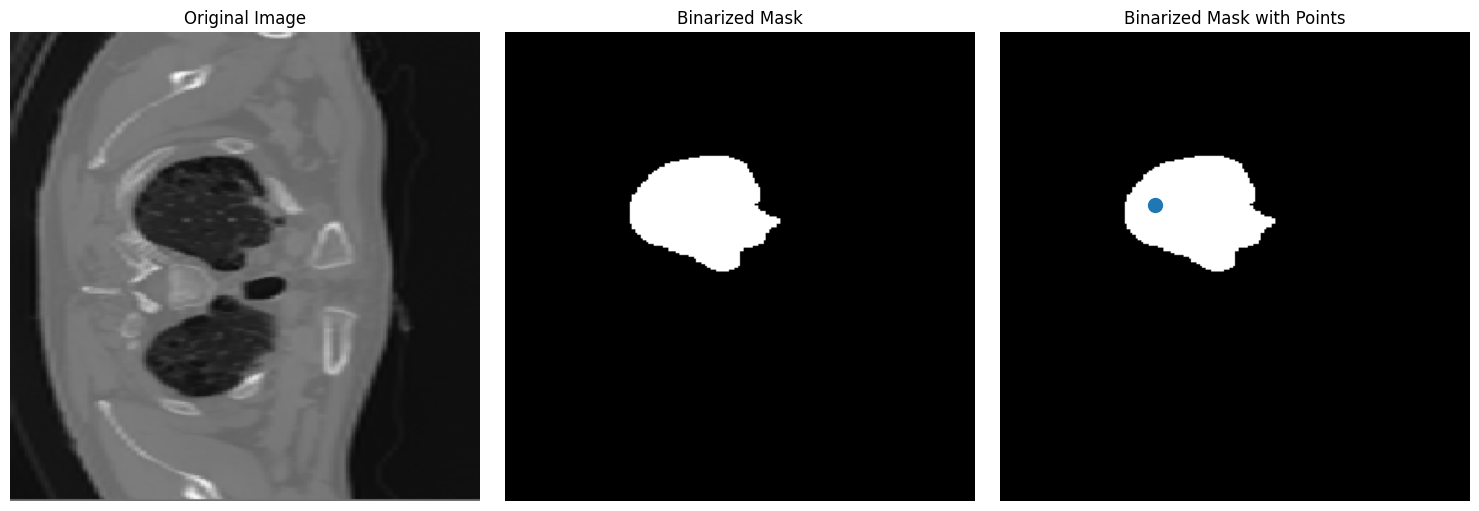

In [ ]:
def read_batch(data, visualize_data=False):
   # Select a random entry
   ent = data[np.random.randint(len(data))]

   # Get full paths
   Img = cv2.imread(ent["image"])[..., ::-1]  # Convert BGR to RGB
   ann_map = cv2.imread(ent["annotation"], cv2.IMREAD_GRAYSCALE)  # Read annotation as grayscale

   if Img is None or ann_map is None:
       print(f"Error: Could not read image or mask from path {ent['image']} or {ent['annotations']}")
       return None, None, None, 0

   # Resize image and mask
   r = np.min([256 / Img.shape[1], 256 / Img.shape[0]])  # Scaling factor
   Img = cv2.resize(Img, (int(Img.shape[1] * r), int(Img.shape[0] * r)))
   ann_map = cv2.resize(ann_map, (int(ann_map.shape[1] * r), int(ann_map.shape[0] * r)), interpolation=cv2.INTER_NEAREST)

   # Initialize a single binary mask
   binary_mask = np.zeros_like(ann_map, dtype=np.uint8)
   points = []

   # Get binary masks and combine them into a single mask
   inds = np.unique(ann_map)[1:]  # Skip the background (index 0)
   for ind in inds:
       mask = (ann_map == ind).astype(np.uint8)  # Create binary mask for each unique index
       binary_mask = np.maximum(binary_mask, mask)  # Combine with the existing binary mask

   # Erode the combined binary mask to avoid boundary points
   eroded_mask = cv2.erode(binary_mask, np.ones((5, 5), np.uint8), iterations=1)

   # Get all coordinates inside the eroded mask and choose a random point
   coords = np.argwhere(eroded_mask > 0)
   if len(coords) > 0:
       for _ in inds:  # Select as many points as there are unique labels
           yx = np.array(coords[np.random.randint(len(coords))])
           points.append([yx[1], yx[0]])

   points = np.array(points)

   if visualize_data:
       # Plotting the images and points
        plt.figure(figsize=(15, 5))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.title('Original Image')
        plt.imshow(Img)
        plt.axis('off')

        # Segmentation Mask (binary_mask)
        plt.subplot(1, 3, 2)
        plt.title('Binarized Mask')
        plt.imshow(binary_mask, cmap='gray')
        plt.axis('off')

        # Mask with Points in Different Colors
        plt.subplot(1, 3, 3)
        plt.title('Binarized Mask with Points')
        plt.imshow(binary_mask, cmap='gray')

        # Plot points in different colors
        colors = list(mcolors.TABLEAU_COLORS.values())
        for i, point in enumerate(points):
            plt.scatter(point[0], point[1], c=colors[i % len(colors)], s=100, label=f'Point {i+1}')  # Corrected to plot y, x order

        # plt.legend()
        plt.axis('off')

        plt.tight_layout()
        plt.show()

   binary_mask = np.expand_dims(binary_mask, axis=-1)  # Now shape is (1024, 1024, 1)
   binary_mask = binary_mask.transpose((2, 0, 1))
   points = np.expand_dims(points, axis=1)

   # Return the image, binarized mask, points, and number of masks
   return Img, binary_mask, points, len(inds)

# Visualize the data
Img1, masks1, points1, num_masks = read_batch(train_data, visualize_data=True)

##### preprocess with bboxes

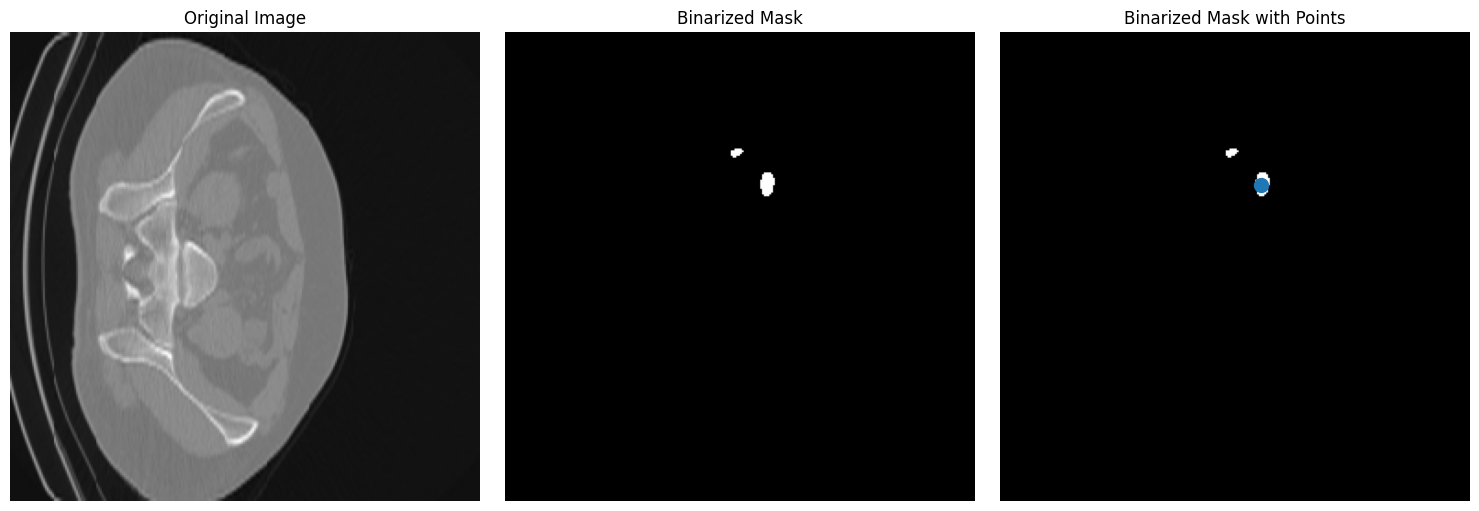

In [ ]:
def read_batch(data, visualize_data=False):
   # Select a random entry
   ent = data[np.random.randint(len(data))]

   # Get full paths
   Img = cv2.imread(ent["image"])[..., ::-1]  # Convert BGR to RGB
   ann_map = cv2.imread(ent["annotations"], cv2.IMREAD_GRAYSCALE)  # Read annotation as grayscale
   bbox = ent["bbox"]

   if Img is None or ann_map is None:
       print(f"Error: Could not read image or mask from path {ent['image']} or {ent['annotations']}")
       return None, None, None, 0

   # Resize image and mask
   r = np.min([256 / Img.shape[1], 256 / Img.shape[0]])  # Scaling factor
   Img = cv2.resize(Img, (int(Img.shape[1] * r), int(Img.shape[0] * r)))
   ann_map = cv2.resize(ann_map, (int(ann_map.shape[1] * r), int(ann_map.shape[0] * r)), interpolation=cv2.INTER_NEAREST)

   # Initialize a single binary mask
   binary_mask = np.zeros_like(ann_map, dtype=np.uint8)
   points = []

   # Get binary masks and combine them into a single mask
   inds = np.unique(ann_map)[1:]  # Skip the background (index 0)
   for ind in inds:
       mask = (ann_map == ind).astype(np.uint8)  # Create binary mask for each unique index
       binary_mask = np.maximum(binary_mask, mask)  # Combine with the existing binary mask

   # Erode the combined binary mask to avoid boundary points
   eroded_mask = cv2.erode(binary_mask, np.ones((5, 5), np.uint8), iterations=1)

   # Get all coordinates inside the eroded mask and choose a random point
   coords = np.argwhere(eroded_mask > 0)
   if len(coords) > 0:
       for _ in inds:  # Select as many points as there are unique labels
           yx = np.array(coords[np.random.randint(len(coords))])
           points.append([yx[1], yx[0]])

   points = np.array(points)

   if visualize_data:
       # Plotting the images and points
        plt.figure(figsize=(15, 5))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.title('Original Image')
        plt.imshow(Img)
        plt.axis('off')

        # Segmentation Mask (binary_mask)
        plt.subplot(1, 3, 2)
        plt.title('Binarized Mask')
        plt.imshow(binary_mask, cmap='gray')
        plt.axis('off')

        # Mask with Points in Different Colors
        plt.subplot(1, 3, 3)
        plt.title('Binarized Mask with Points')
        plt.imshow(binary_mask, cmap='gray')

        # Plot points in different colors
        colors = list(mcolors.TABLEAU_COLORS.values())
        for i, point in enumerate(points):
            plt.scatter(point[0], point[1], c=colors[i % len(colors)], s=100, label=f'Point {i+1}')  # Corrected to plot y, x order

        # plt.legend()
        plt.axis('off')

        plt.tight_layout()
        plt.show()

   binary_mask = np.expand_dims(binary_mask, axis=-1)  # Now shape is (1024, 1024, 1)
   binary_mask = binary_mask.transpose((2, 0, 1))
   points = np.expand_dims(points, axis=1)

   # Return the image, binarized mask, points, and number of masks
   return Img, binary_mask, points, len(inds), bbox

# Visualize the data
Img1, masks1, points1, num_masks, box = read_batch(train_data, visualize_data=True)

#### Training

In [ ]:
sam2_checkpoint = "sam2_hiera_tiny.pt"  # @param ["sam2_hiera_tiny.pt", "sam2_hiera_small.pt", "sam2_hiera_base_plus.pt", "sam2_hiera_large.pt"]
model_cfg = "sam2_hiera_t.yaml" # @param ["sam2_hiera_t.yaml", "sam2_hiera_s.yaml", "sam2_hiera_b+.yaml", "sam2_hiera_l.yaml"]

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device="cuda")
predictor = SAM2ImagePredictor(sam2_model)


In [ ]:
# Train mask decoder.
predictor.model.sam_mask_decoder.train(True)

# Train prompt encoder.
predictor.model.sam_prompt_encoder.train(True)

# Configure optimizer.
optimizer=torch.optim.AdamW(params=predictor.model.parameters(),lr=0.0001,weight_decay=1e-4) #1e-5, weight_decay = 4e-5
# optimizer = torch.optim.SGD(params=predictor.model.parameters(), lr=0.001, momentum=0.9)
# Mix precision.
scaler = torch.cuda.amp.GradScaler()

# No. of steps to train the model.
NO_OF_STEPS = 3500 # @param

# Fine-tuned model name.
FINE_TUNED_MODEL_NAME = "fine_tuned_sam2"


In [ ]:
! export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

##### training with mask only

In [ ]:
# Initialize scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.2) # 500 , 250, gamma = 0.1
accumulation_steps = 1  # Number of steps to accumulate gradients before updating

for step in range(1, NO_OF_STEPS + 1):
   print(step)
   with torch.cuda.amp.autocast():
       image, mask, input_point, num_masks = read_batch(train_data, visualize_data=False)
       if image is None or mask is None or num_masks == 0:
           continue

       input_label = np.ones((num_masks, 1))
       if not isinstance(input_point, np.ndarray) or not isinstance(input_label, np.ndarray):
           continue

       if input_point.size == 0 or input_label.size == 0:
           continue

       predictor.set_image(image)
       mask_input, unnorm_coords, labels, unnorm_box = predictor._prep_prompts(input_point, input_label, box=None, mask_logits=None, normalize_coords=True)
       if unnorm_coords is None or labels is None or unnorm_coords.shape[0] == 0 or labels.shape[0] == 0:
           continue

       sparse_embeddings, dense_embeddings = predictor.model.sam_prompt_encoder(
           points=(unnorm_coords, labels), boxes=None, masks=None,
       )

       batched_mode = unnorm_coords.shape[0] > 1
       high_res_features = [feat_level[-1].unsqueeze(0) for feat_level in predictor._features["high_res_feats"]]
       low_res_masks, prd_scores, _, _ = predictor.model.sam_mask_decoder(
           image_embeddings=predictor._features["image_embed"][-1].unsqueeze(0),
           image_pe=predictor.model.sam_prompt_encoder.get_dense_pe(),
           sparse_prompt_embeddings=sparse_embeddings,
           dense_prompt_embeddings=dense_embeddings,
           multimask_output=True,
           repeat_image=batched_mode,
           high_res_features=high_res_features,
       )
       prd_masks = predictor._transforms.postprocess_masks(low_res_masks, predictor._orig_hw[-1])

       gt_mask = torch.tensor(mask.astype(np.float32)).cuda()
       prd_mask = torch.sigmoid(prd_masks[:, 0])
       seg_loss = (-gt_mask * torch.log(prd_mask + 0.000001) - (1 - gt_mask) * torch.log((1 - prd_mask) + 0.00001)).mean()

       inter = (gt_mask * (prd_mask > 0.5)).sum(1).sum(1)
       iou = inter / (gt_mask.sum(1).sum(1) + (prd_mask > 0.5).sum(1).sum(1) - inter)
       score_loss = torch.abs(prd_scores[:, 0] - iou).mean()
       loss = seg_loss + score_loss * 0.05

       # Apply gradient accumulation
       loss = loss / accumulation_steps
       scaler.scale(loss).backward()

       # Clip gradients
       torch.nn.utils.clip_grad_norm_(predictor.model.parameters(), max_norm=1.0)

       if step % accumulation_steps == 0:
           scaler.step(optimizer)
           scaler.update()
           predictor.model.zero_grad()

       # Update scheduler
       scheduler.step()

       if step % 500 == 0:
           FINE_TUNED_MODEL = FINE_TUNED_MODEL_NAME + "_" + str(step) + ".torch"
           torch.save(predictor.model.state_dict(), FINE_TUNED_MODEL)

       if step == 1:
           mean_iou = 0

       mean_iou = mean_iou * 0.99 + 0.01 * np.mean(iou.cpu().detach().numpy())

       if step % 100 == 0:
           print("Step " + str(step) + ":\t", "Accuracy (IoU) = ", mean_iou)


1


<ipython-input-33-825be869bb6d>:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


ValueError: too many values to unpack (expected 4)

##### training with mask and bboxes per batch

In [ ]:
# Initialize scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.2)
accumulation_steps = 1  # Number of steps to accumulate gradients before updating
device = torch.device("cuda:0")
mean_iou = 0
for step in tqdm(range(1, NO_OF_STEPS + 1)):

    with torch.cuda.amp.autocast():
        image, mask, input_points, num_instances, input_box = read_batch(train_data, visualize_data=False)
        box = np.array(input_box).reshape(1,4)
        if image is None or mask is None or num_instances == 0:
            continue
        input_labels = np.ones((1,num_instances))

        if not isinstance(input_points, np.ndarray) or not isinstance(input_labels, np.ndarray):
            continue

        if input_points.size == 0 or input_labels.size == 0:
            continue

        predictor.set_image(image)

        mask_input, unnorm_coords, labels, unnorm_boxes = predictor._prep_prompts(
            input_points, input_labels, box=box, mask_logits=None, normalize_coords=True
        )


        if unnorm_coords is None or labels is None or unnorm_coords.shape[0] == 0 or labels.shape[0] == 0:
            continue


        sparse_embeddings, dense_embeddings = predictor.model.sam_prompt_encoder(
            points=(unnorm_coords, labels.squeeze(0)), boxes=unnorm_boxes, masks=None,
        )

        batched_mode = unnorm_coords.shape[0] > 1
        high_res_features = [feat_level[-1].unsqueeze(0) for feat_level in predictor._features["high_res_feats"]]
        low_res_masks, prd_scores, _, _ = predictor.model.sam_mask_decoder(
            image_embeddings=predictor._features["image_embed"][-1].unsqueeze(0),
            image_pe=predictor.model.sam_prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=True,
            repeat_image=batched_mode,
            high_res_features=high_res_features,
        )
        prd_masks = predictor._transforms.postprocess_masks(low_res_masks, predictor._orig_hw[-1])

        gt_masks = torch.tensor(mask.astype(np.float32)).cuda()
        prd_masks = torch.sigmoid(prd_masks[:, 0])
        seg_loss = (-gt_masks * torch.log(prd_masks + 1e-6) - (1 - gt_masks) * torch.log((1 - prd_masks) + 1e-6)).mean()

        inter = (gt_masks * (prd_masks > 0.5)).sum(dim=(1, 2))
        iou = inter / (gt_masks.sum(dim=(1, 2)) + (prd_masks > 0.5).sum(dim=(1, 2)) - inter)
        score_loss = torch.abs(prd_scores[:, 0] - iou).mean()
        loss = seg_loss + score_loss * 0.05

        # Apply gradient accumulation
        loss = loss / accumulation_steps
        scaler.scale(loss).backward()

        # Clip gradients
        torch.nn.utils.clip_grad_norm_(predictor.model.parameters(), max_norm=1.0)

        if step % accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            predictor.model.zero_grad()

        # Update scheduler
        scheduler.step()
        mean_iou = mean_iou * 0.99 + 0.01 * np.mean(iou.cpu().detach().numpy())
        if step % 500 == 0:
          FINE_TUNED_MODEL = FINE_TUNED_MODEL_NAME + "_" + str(step) + ".torch"
          torch.save(predictor.model.state_dict(), FINE_TUNED_MODEL)





        if step % 100 == 0:
            print("Step " + str(step) + ":\t", "Accuracy (IoU) = ", mean_iou)


  3%|▎         | 101/3500 [00:12<08:28,  6.69it/s]

Step 100:	 Accuracy (IoU) =  0.34591153


  6%|▌         | 201/3500 [00:24<08:04,  6.80it/s]

Step 200:	 Accuracy (IoU) =  0.5272633


  9%|▊         | 301/3500 [00:37<08:48,  6.05it/s]

...

Step 3300:	 Accuracy (IoU) =  0.749599


 97%|█████████▋| 3401/3500 [07:21<00:12,  8.23it/s]

Step 3400:	 Accuracy (IoU) =  0.745393


100%|██████████| 3500/3500 [07:33<00:00,  7.72it/s]

Step 3500:	 Accuracy (IoU) =  0.7303349


In [ ]:
FINE_TUNED_MODEL = FINE_TUNED_MODEL_NAME + "_" + str(3500) + ".torch"
torch.save(predictor.model.state_dict(), FINE_TUNED_MODEL)


In [ ]:
def read_image(image_path, mask_path):  # read and resize image and mask
   img = cv2.imread(image_path)[..., ::-1]  # Convert BGR to RGB
   mask = cv2.imread(mask_path, 0)
   r = np.min([256 / img.shape[1], 256 / img.shape[0]])
   img = cv2.resize(img, (int(img.shape[1] * r), int(img.shape[0] * r)))
   mask = cv2.resize(mask, (int(mask.shape[1] * r), int(mask.shape[0] * r)), interpolation=cv2.INTER_NEAREST)
   return img, mask

def get_points(mask, num_points):  # Sample points inside the input mask
   points = []
   coords = np.argwhere(mask > 0)
   for i in range(num_points):
       yx = np.array(coords[np.random.randint(len(coords))])
       points.append([[yx[1], yx[0]]])
   return np.array(points)

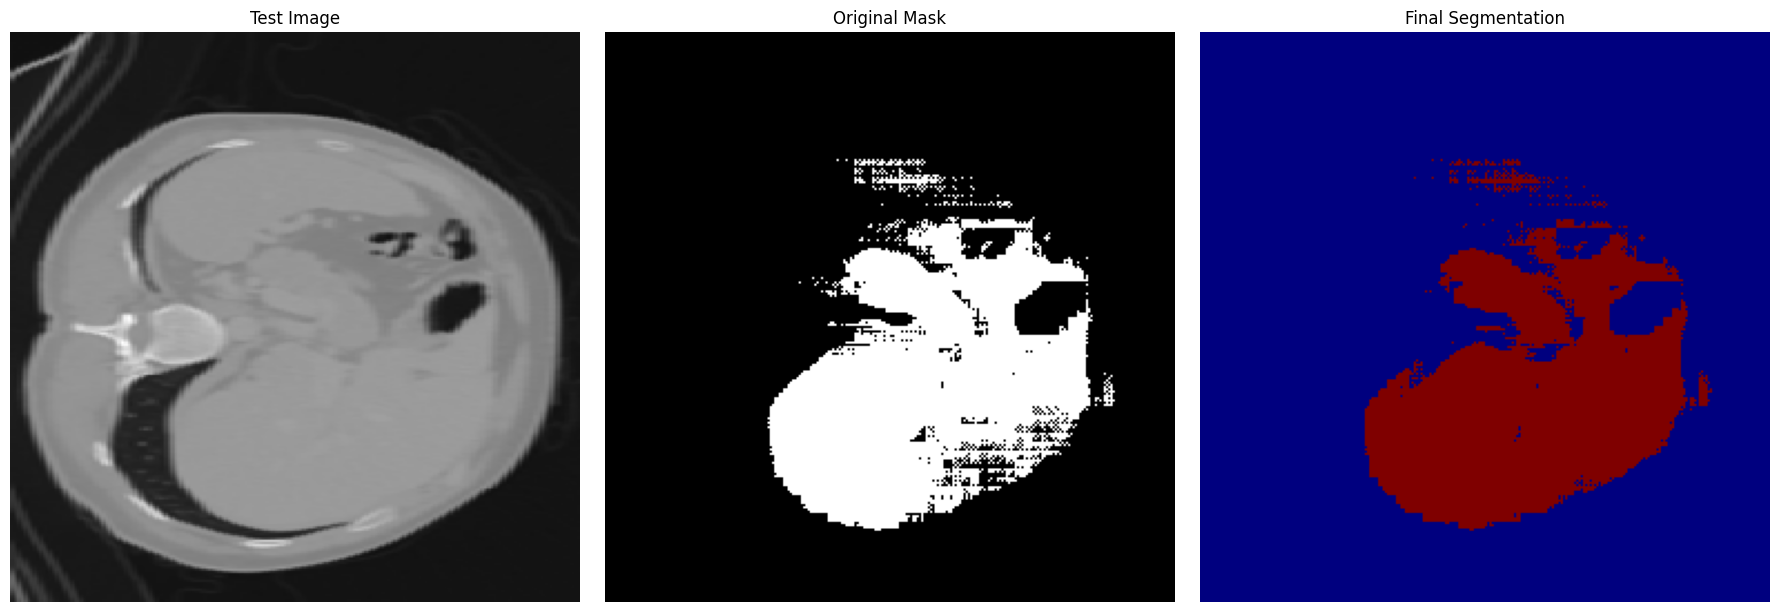

In [ ]:
import random
# Randomly select a test image from the test_data
selected_entry = random.choice(train_data)
image_path = selected_entry['image']
mask_path = selected_entry['annotations']

# Load the selected image and mask
image, mask = read_image(image_path, mask_path)

# Generate random points for the input
num_samples = 30  # Number of points per segment to sample
input_points = get_points(mask, num_samples)

# Load the fine-tuned model
FINE_TUNED_MODEL_WEIGHTS = "fine_tuned_sam2_1000.torch"
sam2_model = build_sam2(model_cfg, sam2_checkpoint, device="cuda")

# Build net and load weights
predictor = SAM2ImagePredictor(sam2_model)
predictor.model.load_state_dict(torch.load(FINE_TUNED_MODEL_WEIGHTS))

# Perform inference and predict masks
with torch.no_grad():
   predictor.set_image(image)
   masks, scores, logits = predictor.predict(
       point_coords=input_points,
       point_labels=np.ones([input_points.shape[0], 1])
   )

# Process the predicted masks and sort by scores
np_masks = np.array(masks[:, 0])
np_scores = scores[:, 0]
sorted_masks = np_masks[np.argsort(np_scores)][::-1]

# Initialize segmentation map and occupancy mask
seg_map = np.zeros_like(sorted_masks[0], dtype=np.uint8)
occupancy_mask = np.zeros_like(sorted_masks[0], dtype=bool)

# Combine masks to create the final segmentation map
for i in range(sorted_masks.shape[0]):
   mask = sorted_masks[i]
   if (mask * occupancy_mask).sum() / mask.sum() > 0.05:
       continue

   mask_bool = mask.astype(bool)
   mask_bool[occupancy_mask] = False  # Set overlapping areas to False in the mask
   seg_map[mask_bool] = i + 1  # Use boolean mask to index seg_map
   occupancy_mask[mask_bool] = True  # Update occupancy_mask

# Visualization: Show the original image, mask, and final segmentation side by side
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title('Test Image')
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Original Mask')
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Final Segmentation')
plt.imshow(seg_map, cmap='jet')
plt.axis('off')

plt.tight_layout()
plt.show()

# Full inference pipeline

In [ ]:
import torch
import numpy as np
from ultralytics import YOLO


# Set device for computation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Load the YOLO model
# -------------------------
yolo_model = YOLO("../runs/detect/train/weights/best.pt")


# -------------------------
# Load the SAM model
# -------------------------
FINE_TUNED_MODEL_WEIGHTS = "fine_tuned_sam2_3000.torch"
sam2_model = build_sam2(model_cfg, sam2_checkpoint, device="cuda")

# Build net and load weights
predictor = SAM2ImagePredictor(sam2_model)
predictor.model.load_state_dict(torch.load(FINE_TUNED_MODEL_WEIGHTS))

<All keys matched successfully>

In [ ]:
import numpy as np

def yolo_to_xyxy(yolo_boxes, img_width, img_height):
    """
    Convert YOLO format (x_center, y_center, width, height)
    to (x_min, y_min, x_max, y_max).

    :param yolo_boxes: List of YOLO annotations [class_id, x_center, y_center, width, height]
    :param img_width: Width of the image
    :param img_height: Height of the image
    :return: List of bounding boxes in (class_id, x_min, y_min, x_max, y_max) format
    """
    xyxy_boxes = []

    for box in yolo_boxes:
        x_center, y_center, width, height = box

        # Convert normalized values to pixel values
        x_center *= img_width
        y_center *= img_height
        width *= img_width
        height *= img_height

        # Compute (x_min, y_min, x_max, y_max)
        x_min = int(x_center - (width / 2))
        y_min = int(y_center - (height / 2))
        x_max = int(x_center + (width / 2))
        y_max = int(y_center + (height / 2))

        xyxy_boxes.append((x_min, y_min, x_max, y_max))

    return xyxy_boxes

In [ ]:
import cv2
import torch
import numpy as np
import random

@torch.no_grad()  # Disable gradients for inference speed.
def yolo_sam2_segmentation(data_slice):
    """
    Performs object detection with YOLOv8 and segmentation with SAM2.

    Args:
        data_slice (np.ndarray): An RGB image as a NumPy array of shape (H, W, 3) in uint8.

    Returns:
        np.ndarray: A segmentation mask (H x W) where each detected object is assigned a unique integer label.
    """
    if len(data_slice.shape) == 2:  # Convert grayscale to RGB
        data_slice = np.stack([data_slice] * 3, axis=-1)

    # Detect objects with YOLOv8
    results = yolo_model(data_slice, conf=0.01)
    boxes = yolo_to_xyxy(results[0].boxes.xywhn.cpu().numpy(), data_slice.shape[1], data_slice.shape[0])
    clses = results[0].boxes.cls

    if len(boxes) == 0:
        return np.zeros(data_slice.shape[:2], dtype=np.int32)

    # Initialize segmentation map and occupancy mask
    final_mask = np.zeros(data_slice.shape[:2], dtype=np.int32)
    occupancy_mask = np.zeros_like(final_mask, dtype=bool)

    predictor.set_image(data_slice)

    for i, bbox in enumerate(boxes):
        x1, y1, x2, y2 = bbox
        box = np.array([x1, y1, x2, y2], dtype=np.float32)
        cls = clses[i]

        # Run SAM2 segmentation for the given bounding box
        masks, scores, logits = predictor.predict(box=box, multimask_output=True)

        best_idx = np.argmax(scores)
        sam_mask = masks[best_idx].astype(bool)

        # Avoid excessive overlap with previously assigned masks
        if (sam_mask * occupancy_mask).sum() / sam_mask.sum() > 0.10:
            continue

        sam_mask[occupancy_mask] = False  # Remove overlapping areas
        final_mask[sam_mask] = cls.cpu() + 1
        occupancy_mask[sam_mask] = True

    return final_mask


In [ ]:
import cv2
import torch
import numpy as np
import random

@torch.no_grad()  # Disable gradients for inference speed.
def yolo_sam2_segmentation_batch(data_slice):
    """
    Performs object detection with YOLOv8 and segmentation with SAM2.

    Args:
        data_slice (np.ndarray): An RGB image as a NumPy array of shape (H, W, 3) in uint8.

    Returns:
        np.ndarray: A segmentation mask (H x W) where each detected object is assigned a unique integer label.
    """
    if len(data_slice.shape) == 2:  # Convert grayscale to RGB
        data_slice = np.stack([data_slice] * 3, axis=-1)

    # Detect objects with YOLOv8
    results = yolo_model(data_slice, conf=0.02)
    boxes = yolo_to_xyxy(results[0].boxes.xywhn.cpu().numpy(), data_slice.shape[1], data_slice.shape[0])
    clses = results[0].boxes.cls

    if len(boxes) == 0:
        return np.zeros(data_slice.shape[:2], dtype=np.int32)

    # Initialize segmentation map and occupancy mask
    final_mask = np.zeros(data_slice.shape[:2], dtype=np.int32)
    occupancy_mask = np.zeros_like(final_mask, dtype=bool)

    predictor.set_image(data_slice)

    # Convert boxes to the required format for batch inference
    batched_boxes = np.array(boxes)
    masks, scores, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=batched_boxes,
        multimask_output=False,
    )

    for i, mask in enumerate(masks):
      class_id = clses[i].cpu() +1
      mask = mask.astype(bool)
      mask_np = mask.squeeze().astype(bool)  # Squeeze to remove extra dimensions
      final_mask[mask_np & ~occupancy_mask] = class_id
      occupancy_mask |= mask_np


    return final_mask

In [ ]:
if len(data_train[12].shape) == 2:  # Shape: (H, W)
      data_slice = np.stack([data_train[12]] * 3, axis=-1)

results = yolo_model(data_slice, conf=0.06)
clses = results[0].boxes.cls.unsqueeze(1).cpu().numpy()
# get the class associated to a box
boxes = yolo_to_xyxy(results[0].boxes.xywhn.cpu().numpy(), 256, 256)
list_box = []

for i, box in enumerate(boxes):
  x_min, y_min, x_max, y_max  = box
  cls = int(clses[i])
  list_box.append((cls, x_min, y_min, x_max, y_max))


0: 640x640 1 8, 1 17, 1 22, 1 23, 3 30s, 2 46s, 12.2ms
Speed: 2.9ms preprocess, 12.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


<ipython-input-175-e3ea5a6cfd11>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cls = int(clses[i])


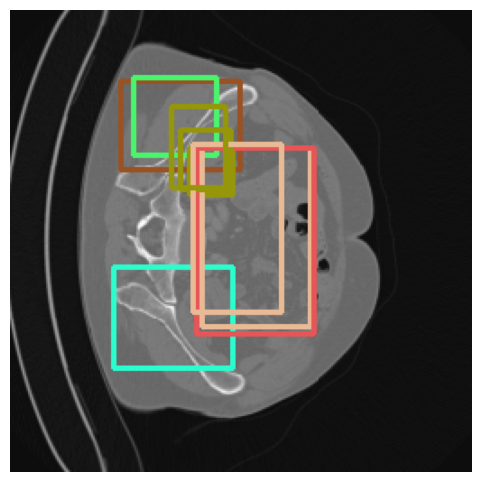

In [ ]:
show_image_with_boxes(data_train[12], list_box)


0: 640x640 3 3s, 15 8s, 1 17, 5 18s, 3 22s, 5 23s, 2 30s, 3 31s, 2 33s, 1 43, 16 46s, 1 47, 12.7ms
Speed: 4.5ms preprocess, 12.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


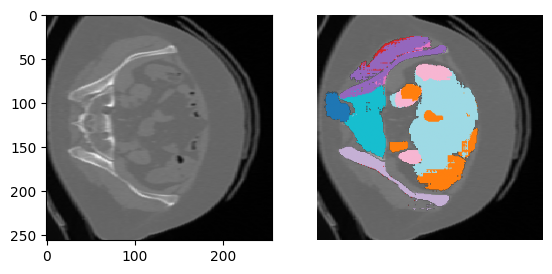

In [ ]:
# Let's display the results
plot_slice_seg(data_train[0], yolo_sam2_segmentation_batch(data_train[0]))

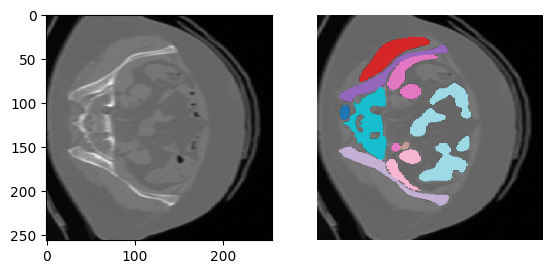

In [ ]:
plot_slice_seg(data_train[], labels_train.iloc[0].values.reshape((256,256)))

In [ ]:
import os
os.environ["LC_ALL"] = "C.UTF-8"
os.environ["LANG"] = "C.UTF-8"


## Fix match Algorithm with unlabelled sample

In [ ]:
# Which are the missing data ?
print(labels_train.iloc[800:2000].sum().sum() )

#Data from 800 to 2000 is missing labels, let's annotate them


0


In [ ]:
def annotate_missing_data(data):
  result_labels = final_mask = np.zeros((data.shape[0],data.shape[1],data.shape[2]), dtype=np.int32)
  for i, d in enumerate(tqdm(data, desc="Processing Images")):
    result_labels[i] = yolo_sam_segmentation(d)
  return result_labels

In [ ]:
print(annotate_missing_data(data_train[800:2000]))

Processing Images:   0%|          | 0/1200 [00:00<?, ?it/s]


0: 640x640 (no detections), 12.0ms
Speed: 8.2ms preprocess, 12.0ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 7.7ms
Speed: 3.0ms preprocess, 7.7ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 7.7ms
Speed: 2.7ms preprocess, 7.7ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 cake, 7.9ms
Speed: 2.8ms preprocess, 7.9ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


Processing Images:   0%|          | 4/1200 [00:02<10:31,  1.89it/s]


0: 640x640 1 remote, 7.1ms
Speed: 3.8ms preprocess, 7.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


Processing Images:   0%|          | 5/1200 [00:04<18:28,  1.08it/s]

...


0: 640x640 (no detections), 12.0ms
Speed: 4.1ms preprocess, 12.0ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 12.9ms
Speed: 3.8ms preprocess, 12.9ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 remote, 1 clock, 12.8ms
Speed: 5.7ms preprocess, 12.8ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


Processing Images:   6%|▌         | 66/1200 [00:50<14:43,  1.28it/s]


0: 640x640 (no detections), 7.0ms
Speed: 3.8ms preprocess, 7.0ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 tie, 7.9ms
Speed: 3.2ms preprocess, 7.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


Processing Images:   6%|▌         | 67/1200 [00:52<14:42,  1.28it/s]


KeyboardInterrupt: 

## Let's measure its performances

In [ ]:
# Compute the baseline on a whole dataset
def compute_baseline(dataset: np.array):
    labels_predicted_list = []
    for data_index in tqdm(range(len(dataset))):
        data_slice = dataset[data_index]
        label_predicted = yolo_sam2_segmentation_batch(data_slice)
        labels_predicted_list.append(label_predicted)
    # return pd.DataFrame(np.stack(labels_predicted_list, axis=0).reshape((len(labels_predicted_list), -1)))
    return np.stack(labels_predicted_list, axis=0)

In [ ]:
# Let's create a validation set first: the 200 first images of the train set
data_val = data_train[:200]
labels_val = labels_train.iloc[:200]

In [ ]:
# Compute baseline on a few train data
labels_val_predicted_baseline = compute_baseline(data_val)

  0%|          | 0/200 [00:00<?, ?it/s]


0: 640x640 1 3, 1 4, 1 15, 2 17s, 2 18s, 1 22, 1 23, 1 29, 2 30s, 2 31s, 1 32, 1 43, 5 46s, 15.5ms
Speed: 5.3ms preprocess, 15.5ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


  0%|          | 1/200 [00:00<02:02,  1.63it/s]


0: 640x640 1 3, 1 4, 1 8, 1 30, 1 31, 1 32, 1 33, 1 34, 1 35, 6 46s, 1 52, 10.2ms
Speed: 4.5ms preprocess, 10.2ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


  1%|          | 2/200 [00:01<01:52,  1.76it/s]

...

 99%|█████████▉| 198/200 [01:36<00:00,  2.75it/s]


0: 640x640 1 4, 1 8, 1 15, 1 16, 1 17, 2 18s, 1 19, 1 22, 1 23, 1 26, 1 30, 2 31s, 1 43, 5 46s, 8.0ms
Speed: 3.9ms preprocess, 8.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


100%|█████████▉| 199/200 [01:36<00:00,  2.59it/s]


0: 640x640 1 8, 1 15, 2 16s, 1 17, 5 18s, 1 19, 1 22, 1 23, 2 26s, 3 29s, 2 30s, 1 31, 2 43s, 7 46s, 10.4ms
Speed: 4.1ms preprocess, 10.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


100%|██████████| 200/200 [01:37<00:00,  2.05it/s]


In [ ]:
NUM_CLASSES = 54 # 55 classes in total, but the first one is the background


def dice_image(prediction, ground_truth):
    intersection = np.sum(prediction * ground_truth)
    if np.sum(prediction) == 0 and np.sum(ground_truth) == 0:
        return np.nan
    return 2 * intersection / (np.sum(prediction) + np.sum(ground_truth))


def dice_multiclass(prediction, ground_truth):
    dices = []
    for i in range(1, NUM_CLASSES + 1): # skip background
        dices.append(dice_image(prediction == i, ground_truth == i))
    return np.array(dices)

def dice_pandas(y_true_df: pd.DataFrame, y_pred_df: pd.DataFrame) -> float:
    """Compute the dice score for each sample in the dataset and then average it"""
    y_pred_df = y_pred_df.T
    y_true_df = y_true_df.T
    individual_dice = []
    for row_index in range(y_true_df.values.shape[0]):
        dices = dice_multiclass(y_true_df.values[row_index].ravel(), y_pred_df.values[row_index].ravel())
        individual_dice.append(dices)

    final = np.stack(individual_dice)
    # First, average over images for each class
    # Then, average over classes
    cls_dices = np.nanmean(final, axis=0)
    return float(np.nanmean(cls_dices))


In [ ]:
# Compute the metric on the validation set
dice_pandas(labels_val, labels_val_predicted_baseline)
# We get => (0.0011196021617737601); Not so bad, but room for improvements!
# Let's see if you can do better!

AttributeError: 'numpy.ndarray' object has no attribute 'values'

# generate labels for test set

In [ ]:
labels_test = compute_baseline(data_test)

  0%|          | 0/500 [00:00<?, ?it/s]


0: 640x640 1 30, 2 33s, 2 35s, 1 47, 1 52, 10.5ms
Speed: 3.5ms preprocess, 10.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


  0%|          | 1/500 [00:00<02:13,  3.75it/s]


0: 640x640 1 8, 1 17, 1 23, 1 31, 1 33, 2 35s, 2 47s, 10.0ms
Speed: 3.5ms preprocess, 10.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


  0%|          | 2/500 [00:00<01:51,  4.46it/s]

...

100%|█████████▉| 498/500 [02:52<00:00,  2.40it/s]


0: 640x640 1 2, 5 3s, 11 4s, 1 8, 1 21, 1 36, 1 37, 8 41s, 15 42s, 1 44, 2 47s, 1 48, 7 53s, 16.3ms
Speed: 4.0ms preprocess, 16.3ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


100%|█████████▉| 499/500 [02:53<00:00,  2.42it/s]


0: 640x640 4 2s, 13 3s, 11 4s, 1 17, 1 35, 1 36, 3 37s, 6 41s, 18 42s, 2 44s, 1 47, 1 52, 5 53s, 16.2ms
Speed: 3.7ms preprocess, 16.2ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


100%|██████████| 500/500 [02:53<00:00,  2.88it/s]


In [ ]:
# save the labels to a .csv format as the train.csv
labels_test = labels_test.T

In [ ]:
labels_test.head()

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [ ]:
pd.DataFrame(labels_test.reshape((labels_test.shape[0], -1))).T.to_csv("y_test.csv")

In [ ]:
labels_test.shape

(500, 256, 256)

In [ ]:

# Save to CSV: each row corresponds to a pixel, each column to an image
labels_test.to_csv("segmentation_results.csv", index=[f"Pixel {i}" for i in range(256*256)], header=[f"{i}.png" for i in range(labels_test.shape[1])])


In [ ]:
!pwd

/content/segment-anything-2


In [ ]:
pd.DataFrame(labels_test.reshape((labels_test.shape[0], -1))).T.to_csv("y_test.csv", index=[f"Pixel {i}" for i in range(256*256)], header=[f"{i}.png" for i in range(500)] )

In [ ]:
import pandas as pd

# Assuming labels_test is your data array
# Reshape the data if necessary
reshaped_data = labels_test.reshape((labels_test.shape[0], -1)).T

# Create a DataFrame
df = pd.DataFrame(reshaped_data)

# Set the index and header
df.index = [f"Pixel {i}" for i in range(256*256)]
df.columns = [f"{i}.png" for i in range(500)]

# Save to CSV
df.to_csv("y_test.csv")
